In [1]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
#from resonantstate.analyse_samples import *
from resonantstate.ell2SFM import *
from resonantstate.simulations_resonance_analysis import *
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
save_path = Path("./mean_posteriors/")
dataframe_observations = get_metadata_observations()

In [3]:
target = "Kepler-307"
author_id = 1
df_selected = dataframe_observations[dataframe_observations["star_name"].isin([target])]
df_list = download_observations_samples(df_selected,)
samples_dict = df_list[author_id]
print(
    f"""Samples by {samples_dict['author_name']}"
    using a '{samples_dict['mass_prior']}' prior on mass and '{samples_dict['eccentricity_prior']}' 
    prior on eccentricities"""
)

Samples by Hadden"
    using a 'uniform' prior on mass and 'log-uniform' 
    prior on eccentricities


In [4]:
df_samples = samples_dict['samples']
mean_samples_file=f"./{target}_author_{samples_dict['author_name']}"
mean_samples_file+=f"_ecc_prior_{samples_dict['eccentricity_prior']}_mass_prior_{samples_dict['mass_prior']}_mean_posteriors.pkl"
mean_samples_file= save_path / mean_samples_file
print(mean_samples_file)
df_samples_mean = pd.read_pickle(mean_samples_file)

mean_posteriors/Kepler-307_author_Hadden_ecc_prior_log-uniform_mass_prior_uniform_mean_posteriors.pkl


Text(0.5, 1.0, 'Kepler-307')

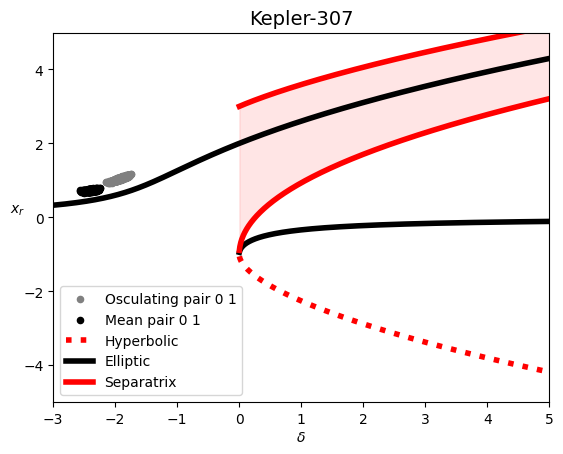

In [5]:
fig,ax = plt.subplots(1)
planet_pair = [0,1]
Pin,Pout = [df_samples[f'period_days_{i}'].median() for i in planet_pair]
p=int(1/(1-Pin/Pout))
plot_samples_SFM_pair(ax,df_samples,planet_pair,p,'gray',flag_DMMR=False,label="Osculating")
plot_samples_SFM_pair(ax,df_samples_mean,planet_pair,p,'k',flag_DMMR=False,label="Mean")
plot_topology(ax)
ax.legend()
ax.set_title(target,fontsize=14)